In [23]:
################################# Libraries #################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import shap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


warnings.filterwarnings('ignore')
print("Βιβλιοθήκες φορτώθηκαν. Έτοιμοι για την προεπεξεργασία των 5G δεδομένων.")

Βιβλιοθήκες φορτώθηκαν. Έτοιμοι για την προεπεξεργασία των 5G δεδομένων.


In [24]:
# Φόρτωση
train_df = pd.read_csv('/Users/antonistsipoulakos/Downloads/UNSW_NB15_training-set(in).csv')
test_df = pd.read_csv('/Users/antonistsipoulakos/Downloads/UNSW_NB15_testing-set(in).csv')

print(f" Αρχικό μέγεθος Train: {train_df.shape}")

# Καθαρισμός Δεδομένων βάσει λογικής 
# Διαγράφουμε το 'id' (αύξων αριθμός) και το 'attack_cat' (λεπτομέρειες επίθεσης) 
# γιατί κάνουμε Δυαδική Κατηγοριοποίηση (Normal vs Attack).

train_df = train_df.drop(['id', 'attack_cat'], axis=1)
test_df = test_df.drop(['id', 'attack_cat'], axis=1)

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(" Διαγράφηκαν οι στήλες 'id' και 'attack_cat' ως μη σχετικές με τη δυαδική πρόβλεψη.")
print(f" Διαχωρισμός ολοκληρώθηκε. Στόχος (Label): 0 = Normal, 1 = Attack.")

 Αρχικό μέγεθος Train: (175341, 45)
 Διαγράφηκαν οι στήλες 'id' και 'attack_cat' ως μη σχετικές με τη δυαδική πρόβλεψη.
 Διαχωρισμός ολοκληρώθηκε. Στόχος (Label): 0 = Normal, 1 = Attack.


In [25]:
print(" Μετατροπή ποιοτικών χαρακτηριστικών (proto, service, state) σε Dummy variables...")
categorical_cols = ['proto', 'service', 'state']
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Ευθυγράμμιση: Αν το Test έχει λιγότερα πρωτόκολλα από το Train, γεμίζουμε με 0.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0) 

print(f" Μετά τα Dummies, οι στήλες αυξήθηκαν σε: {X_train.shape[1]}")

print(" Εφαρμογή Min-Max Scaling στο διάστημα [0, 1]...")
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f" Η κανονικοποίηση ολοκληρώθηκε. Ελάχιστο: {X_train.min().min()}, Μέγιστο: {X_train.max().max()}")

 Μετατροπή ποιοτικών χαρακτηριστικών (proto, service, state) σε Dummy variables...
 Μετά τα Dummies, οι στήλες αυξήθηκαν σε: 194
 Εφαρμογή Min-Max Scaling στο διάστημα [0, 1]...
 Η κανονικοποίηση ολοκληρώθηκε. Ελάχιστο: 0.0, Μέγιστο: 1.0000000000000002


In [26]:
def objective(trial):
    # Παράμετροι που ζητάει η εκφώνηση (eta/learning_rate, gamma, max_depth)
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**param)
    
    # 10-fold Cross Validation (Απαίτηση εκφώνησης)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    return np.mean(scores)

print(" Έναρξη βελτιστοποίησης υπερπαραμέτρων (Optuna Tuning)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # Μπορείς να το κάνεις 20 ή 30 για την τελική αναφορά

print("\n Tuning Ολοκληρώθηκε!")
print(f"Καλύτερες Παράμετροι: {study.best_params}")
print(f"Καλύτερη Ακρίβεια στο Train (CV Score): {study.best_value:.4f}")

# Εκπαίδευση τελικού μοντέλου
print(" Εκπαίδευση τελικού XGBoost με τις βέλτιστες παραμέτρους...")
final_xgb_model = xgb.XGBClassifier(**{**study.best_params, 'objective': 'binary:logistic', 'eval_metric': 'logloss'})
final_xgb_model.fit(X_train, y_train)
print(" Το μοντέλο εκπαιδεύτηκε και είναι έτοιμο για αξιολόγηση.")

 Έναρξη βελτιστοποίησης υπερπαραμέτρων (Optuna Tuning)...

 Tuning Ολοκληρώθηκε!
Καλύτερες Παράμετροι: {'learning_rate': 0.19446502248952038, 'max_depth': 7, 'gamma': 0.4962447142240948, 'n_estimators': 111}
Καλύτερη Ακρίβεια στο Train (CV Score): 0.9593
 Εκπαίδευση τελικού XGBoost με τις βέλτιστες παραμέτρους...
 Το μοντέλο εκπαιδεύτηκε και είναι έτοιμο για αξιολόγηση.


 Αξιολόγηση μοντέλου στο Test Set (Αόρατα δεδομένα)...

       ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ XGBOOST
 Accuracy:  87.55% (Συνολική ορθότητα)
 Precision: 0.8242 (Πόσο έγκυρος είναι ο συναγερμός επίθεσης)
 Recall:    0.9837 (Πόσες από τις πραγματικές επιθέσεις βρήκαμε)
  F1-Score:  0.8969 (Ισορροπία Precision/Recall)
  ROC AUC:   0.9838 (Ικανότητα διαχωρισμού normal/attack)

 Δημιουργία καμπύλης ROC...


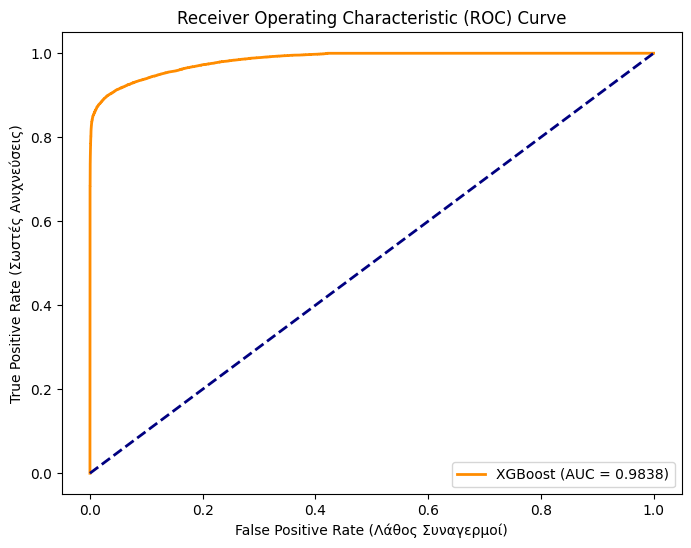

In [27]:
print(" Αξιολόγηση μοντέλου στο Test Set (Αόρατα δεδομένα)...")
y_pred = final_xgb_model.predict(X_test)
y_proba = final_xgb_model.predict_proba(X_test)[:, 1] 

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n" + "="*40)
print("       ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ XGBOOST")
print("="*40)
print(f" Accuracy:  {acc*100:.2f}% (Συνολική ορθότητα)")
print(f" Precision: {prec:.4f} (Πόσο έγκυρος είναι ο συναγερμός επίθεσης)")
print(f" Recall:    {rec:.4f} (Πόσες από τις πραγματικές επιθέσεις βρήκαμε)")
print(f"  F1-Score:  {f1:.4f} (Ισορροπία Precision/Recall)")
print(f"  ROC AUC:   {roc_auc:.4f} (Ικανότητα διαχωρισμού normal/attack)")
print("="*40)

# Γράφημα
print("\n Δημιουργία καμπύλης ROC...")
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Λάθος Συναγερμοί)')
plt.ylabel('True Positive Rate (Σωστές Ανιχνεύσεις)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Υπολογισμός SHAP values για το μοντέλο XGBoost (TreeExplainer)...
Δημιουργία γραφημάτων SHAP...


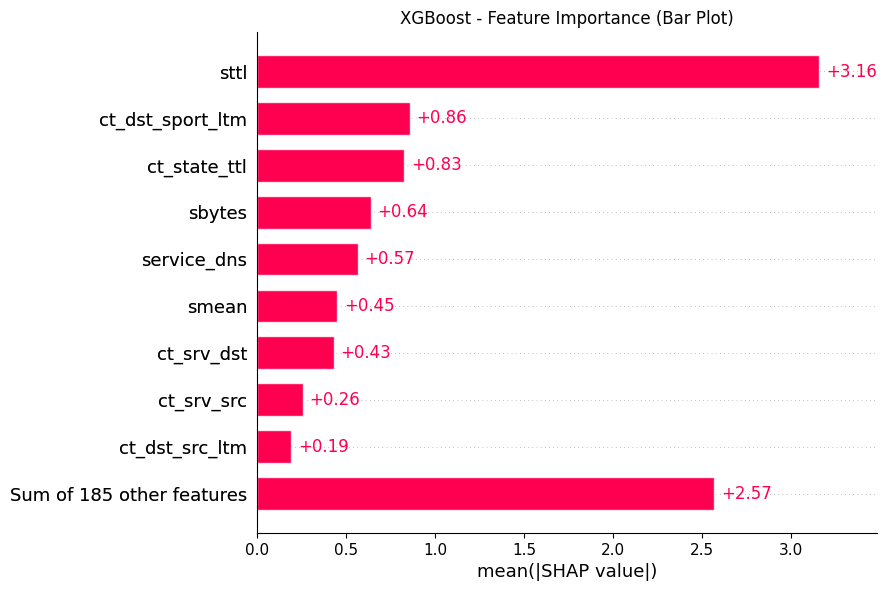

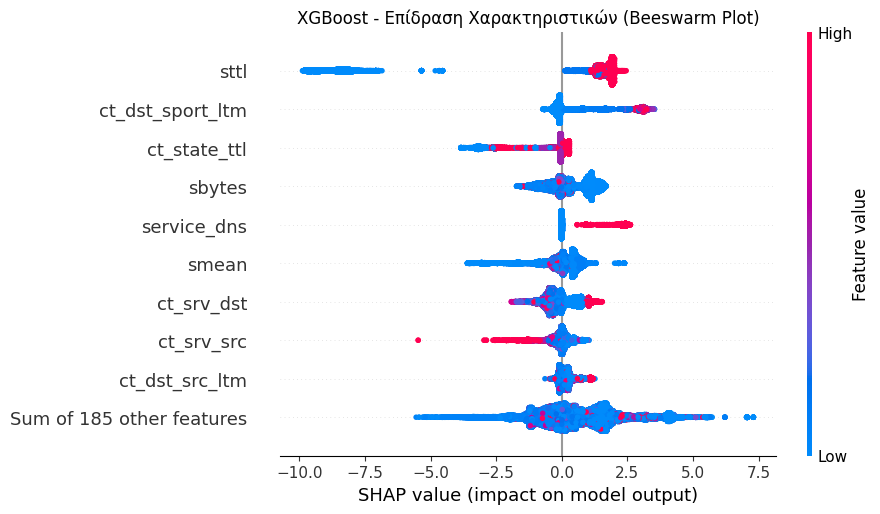

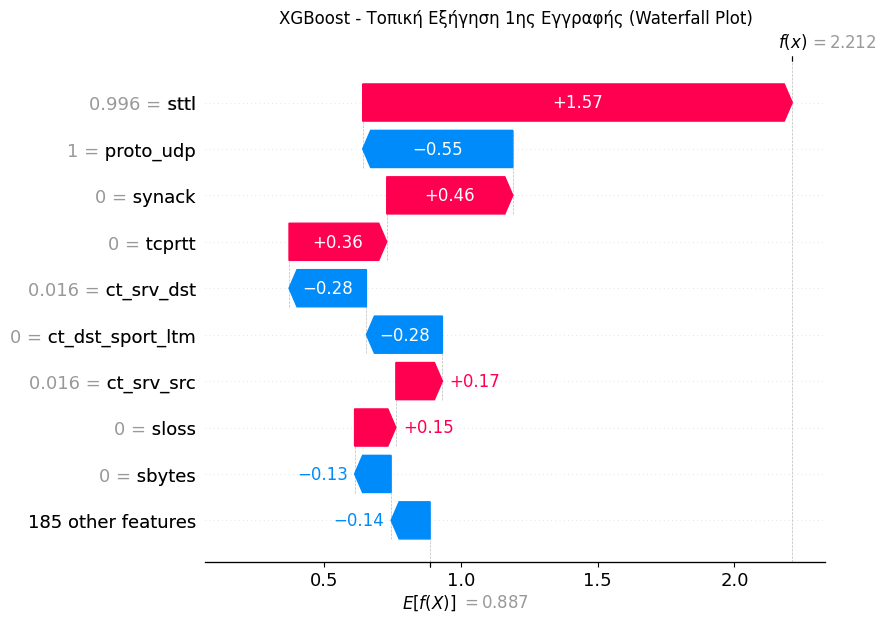

In [28]:

# Απαραίτητο για να εμφανίζονται σωστά κάποια διαδραστικά γραφήματα στο Jupyter
shap.initjs() 

print("Υπολογισμός SHAP values για το μοντέλο XGBoost (TreeExplainer)...")

# 1. Δημιουργία του Explainer χρησιμοποιώντας το εκπαιδευμένο XGBoost μοντέλο
explainer_xgb = shap.TreeExplainer(final_xgb_model)

# 2. Υπολογισμός των SHAP values πάνω στο Test Set
shap_values_xgb = explainer_xgb(X_test)

print("Δημιουργία γραφημάτων SHAP...")

# 3. Bar Plot: Ποια χαρακτηριστικά (features) είναι συνολικά τα πιο σημαντικά
plt.figure()
plt.title("XGBoost - Feature Importance (Bar Plot)")
shap.plots.bar(shap_values_xgb, max_display=10)
plt.show()

# 4. Beeswarm Plot: Πώς ακριβώς επηρεάζει το κάθε χαρακτηριστικό την πρόβλεψη;
plt.figure()
plt.title("XGBoost - Επίδραση Χαρακτηριστικών (Beeswarm Plot)")
shap.plots.beeswarm(shap_values_xgb, max_display=10)
plt.show()

# 5. Waterfall Plot: Εξήγηση μιας συγκεκριμένης πρόβλεψης (π.χ. της πρώτης εγγραφής του Test Set)
plt.figure()
plt.title("XGBoost - Τοπική Εξήγηση 1ης Εγγραφής (Waterfall Plot)")
shap.plots.waterfall(shap_values_xgb[0])
plt.show()

 Ξεκινάει η δοκιμή για το Νευρωνικό Δίκτυο (MLP)...
 Έναρξη βελτιστοποίησης υπερπαραμέτρων MLP (5 Δοκιμές)...


  0%|          | 0/5 [00:00<?, ?it/s]/Users/antonistsipoulakos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/antonistsipoulakos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered


 Tuning Νευρωνικού Ολοκληρώθηκε!
Καλύτερες Παράμετροι: {'n_layers': 3, 'n_units_l0': 86, 'n_units_l1': 37, 'n_units_l2': 27, 'activation': 'tanh', 'alpha': 2.3414518079694325e-05, 'learning_rate_init': 0.000311652096389707}
Καλύτερη Ακρίβεια (CV Score): 0.9461

 Εκπαίδευση τελικού MLP Νευρωνικού...
 Το Νευρωνικό Δίκτυο εκπαιδεύτηκε!
 Αξιολόγηση στο Test Set...

    ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ MLP (NEURAL NET)
 Accuracy:  86.09%
 Precision: 0.8083
 Recall:    0.9797
  F1-Score:  0.8858
  ROC AUC:   0.9792

 Δημιουργία συγκριτικής καμπύλης ROC...


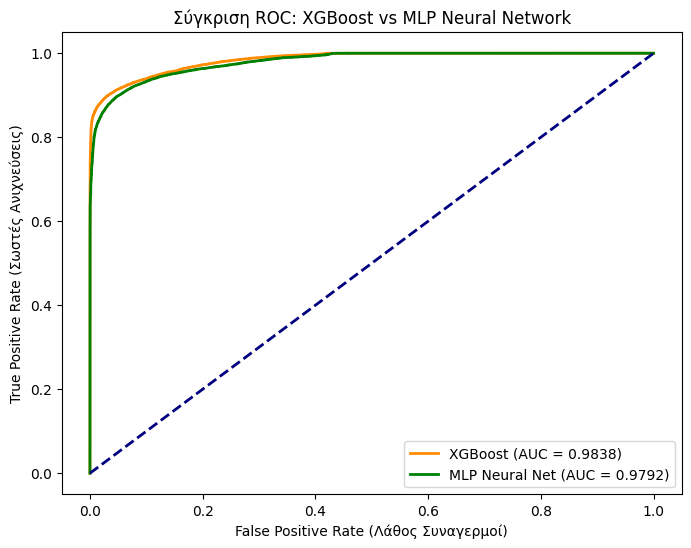

In [29]:
import warnings
warnings.filterwarnings('ignore') 

from sklearn.neural_network import MLPClassifier
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print(" Ξεκινάει η δοκιμή για το Νευρωνικό Δίκτυο (MLP)...")

def objective_mlp(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 16, 128))
        
    param = {
        'hidden_layer_sizes': tuple(layers),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter': 200, 
        'random_state': 42
    }
    
    model = MLPClassifier(**param)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    return np.mean(scores)

print(" Έναρξη βελτιστοποίησης υπερπαραμέτρων MLP (5 Δοκιμές)...")
# Κρύβουμε και τα περιττά μηνύματα της ίδιας της Optuna για να βλέπεις μόνο την ουσία
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_mlp = optuna.create_study(direction='maximize')
# Βάζουμε 5 δοκιμές για να μη σε κουράζει η αναμονή
study_mlp.optimize(objective_mlp, n_trials=5, show_progress_bar=True) 

print("\n Tuning Νευρωνικού Ολοκληρώθηκε!")
print(f"Καλύτερες Παράμετροι: {study_mlp.best_params}")
print(f"Καλύτερη Ακρίβεια (CV Score): {study_mlp.best_value:.4f}")




# ==========================================
# ΕΚΠΑΙΔΕΥΣΗ & ΑΞΙΟΛΟΓΗΣΗ ΤΕΛΙΚΟΥ ΜΟΝΤΕΛΟΥ
# ==========================================
print("\n Εκπαίδευση τελικού MLP Νευρωνικού...")

best_n_layers = study_mlp.best_params['n_layers']
best_layers = tuple([study_mlp.best_params[f'n_units_l{i}'] for i in range(best_n_layers)])

final_mlp_model = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation=study_mlp.best_params['activation'],
    alpha=study_mlp.best_params['alpha'],
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    max_iter=300,
    random_state=42
)

final_mlp_model.fit(X_train, y_train)
print(" Το Νευρωνικό Δίκτυο εκπαιδεύτηκε!")

print(" Αξιολόγηση στο Test Set...")
y_pred_mlp = final_mlp_model.predict(X_test)
y_proba_mlp = final_mlp_model.predict_proba(X_test)[:, 1] 

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp)
rec_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)
roc_auc_mlp = roc_auc_score(y_test, y_proba_mlp)

print("\n" + "="*40)
print("    ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ MLP (NEURAL NET)")
print("="*40)
print(f" Accuracy:  {acc_mlp*100:.2f}%")
print(f" Precision: {prec_mlp:.4f}")
print(f" Recall:    {rec_mlp:.4f}")
print(f"  F1-Score:  {f1_mlp:.4f}")
print(f"  ROC AUC:   {roc_auc_mlp:.4f}")
print("="*40)

# Γράφημα Συγκριτικής ROC Curve (XGBoost vs MLP)
print("\n Δημιουργία συγκριτικής καμπύλης ROC...")
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

plt.figure(figsize=(8, 6))
# Βάζουμε και το XGBoost (αφού υπάρχει ήδη στη μνήμη)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot(fpr_mlp, tpr_mlp, color='green', lw=2, label=f'MLP Neural Net (AUC = {roc_auc_mlp:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Λάθος Συναγερμοί)')
plt.ylabel('True Positive Rate (Σωστές Ανιχνεύσεις)')
plt.title('Σύγκριση ROC: XGBoost vs MLP Neural Network')
plt.legend(loc="lower right")
plt.show()

Υπολογισμός SHAP values για το μοντέλο MLP...


100%|██████████| 100/100 [00:16<00:00,  6.06it/s]


Δημιουργία Beeswarm Plot (Summary) για το MLP...


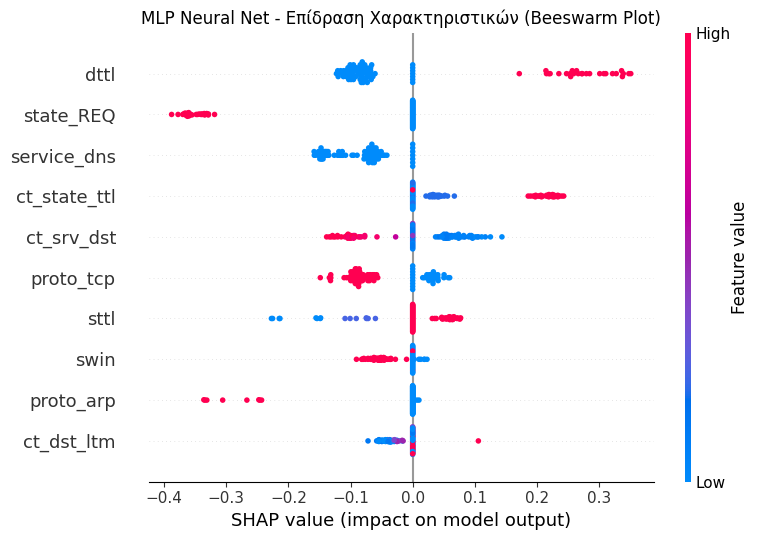

In [30]:
print("Υπολογισμός SHAP values για το μοντέλο MLP...")

# 1. Φτιάχνουμε μια βοηθητική συνάρτηση που επιστρέφει ΜΟΝΟ την πιθανότητα της κλάσης 1 (Attack)
# Αυτό λύνει οριστικά τα προβλήματα διαστάσεων (shape mismatches) του KernelExplainer
def mlp_predict_proba_class1(X):
    return final_mlp_model.predict_proba(X)[:, 1]

# 2. Επιλέγουμε ένα αντιπροσωπευτικό δείγμα 100 εγγραφών από το Train για background data
background_data = shap.sample(X_train, 100)

# 3. Δημιουργία του Explainer χρησιμοποιώντας τη βοηθητική συνάρτηση
explainer_mlp = shap.KernelExplainer(mlp_predict_proba_class1, background_data)

# 4. Υπολογισμός SHAP values για ένα δείγμα 100 εγγραφών του Test Set 
X_test_sample = X_test.iloc[:100]
shap_values_mlp = explainer_mlp.shap_values(X_test_sample)

# Τώρα το shap_values_mlp είναι ένας καθαρός δισδιάστατος πίνακας, 
# οπότε ΔΕΝ χρειάζεται να βάλουμε το [1] στο τέλος!
print("Δημιουργία Beeswarm Plot (Summary) για το MLP...")
plt.figure()
plt.title("MLP Neural Net - Επίδραση Χαρακτηριστικών (Beeswarm Plot)")
shap.summary_plot(shap_values_mlp, X_test_sample, max_display=10)
plt.show()

Δημιουργία Πινάκων Σύγχυσης (Confusion Matrices)...


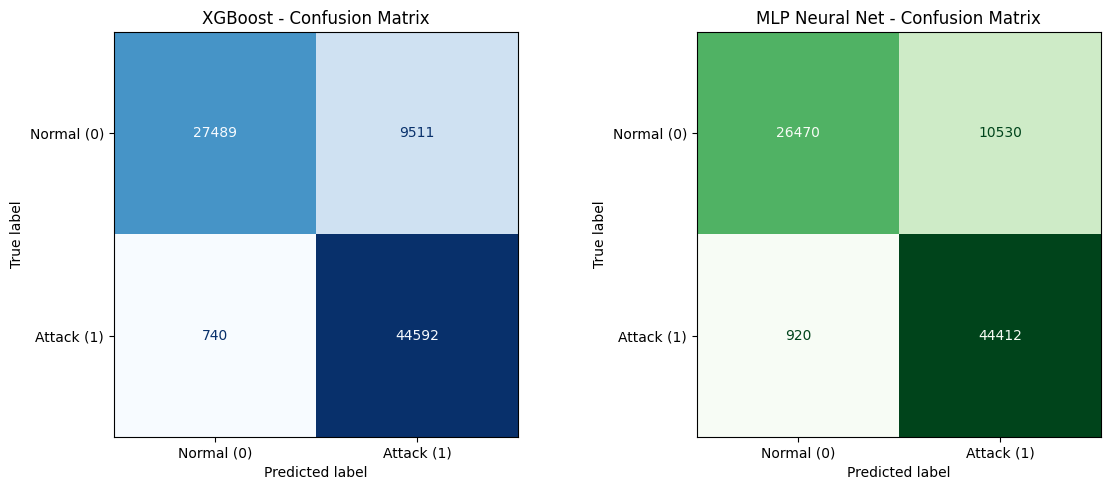

In [31]:
# --- ΑΠΑΡΑΙΤΗΤΑ IMPORTS ΓΙΑ ΤΑ ΓΡΑΦΗΜΑΤΑ ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Δημιουργία Πινάκων Σύγχυσης (Confusion Matrices)...")

# 1. Υπολογισμός των πινάκων σύγχυσης
cm_xgb = confusion_matrix(y_test, y_pred)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

# 2. Ρύθμιση γραφημάτων (1 γραμμή, 2 στήλες για να μπουν δίπλα-δίπλα)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Λίστα με τις ετικέτες μας (0 = Normal, 1 = Attack)
labels = ['Normal (0)', 'Attack (1)']

# 3. Σχεδιασμός για τον XGBoost (με μπλε αποχρώσεις)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=labels)
disp_xgb.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('XGBoost - Confusion Matrix')

# 4. Σχεδιασμός για το MLP (με πράσινες αποχρώσεις)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=labels)
disp_mlp.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('MLP Neural Net - Confusion Matrix')

plt.tight_layout()
plt.show()

In [39]:

import time
import matplotlib.pyplot as plt
from lightshap import explain_tree, explain_any

print("="*40)
print(" 1. ΑΞΙΟΛΟΓΗΣΗ ΧΡΟΝΟΥ ΜΕ LIGHTSHAP ")
print("="*40)

# --- XGBOOST ΜΕ LIGHTSHAP ---
print("Υπολογισμός LightSHAP για XGBoost (Tree Models)...")
start_time_xgb = time.time()

# Το LightSHAP έχει έτοιμη συνάρτηση για δέντρα: explain_tree
expl_xgb = explain_tree(final_xgb_model, X_test) 

time_xgb_light = time.time() - start_time_xgb
print(f"Χρόνος εκτέλεσης XGBoost LightSHAP: {time_xgb_light:.3f} δευτερόλεπτα\n")


# --- MLP ΜΕ LIGHTSHAP ---
print("Υπολογισμός LightSHAP για MLP (Model-Agnostic)...")
# Χρησιμοποιούμε ξανά τη βοηθητική συνάρτηση για να αποφύγουμε λάθη στις διαστάσεις (παίρνουμε την κλάση 1)
def mlp_predict_proba_class1(X):
    return final_mlp_model.predict_proba(X)[:, 1]

start_time_mlp = time.time()

# Στο LightSHAP χρησιμοποιούμε το explain_any για scikit-learn/Νευρωνικά
expl_mlp = explain_any(mlp_predict_proba_class1, X_test_sample)

time_mlp_light = time.time() - start_time_mlp
print(f"Χρόνος εκτέλεσης MLP LightSHAP: {time_mlp_light:.3f} δευτερόλεπτα\n")

print("="*40)
print(" 2. ΔΗΜΙΟΥΡΓΙΑ ΝΕΩΝ ΓΡΑΦΗΜΑΤΩΝ (LIGHTSHAP) ")
print("="*40)

# Το νέο API γραφημάτων είναι πιο απλό. Καλούμε τα γραφήματα κατευθείαν πάνω στο "explanation" object!

print("LightSHAP Bar Plot (XGBoost)...")
expl_xgb.plot.bar()
plt.show()

print("LightSHAP Beeswarm Plot (XGBoost)...")
expl_xgb.plot.beeswarm()
plt.show()

print("LightSHAP Beeswarm Plot (MLP)...")
expl_mlp.plot.beeswarm()
plt.show()

ModuleNotFoundError: No module named 'lightshap'